# Predicting Hospital Readmission in Diabetic Patients
## Notebook 7 of 7 - Cumulative Model Performance Comparison

In this final notebook I rendered **Table I** from my paper - a formatted summary of all eight model configurations I evaluated across `3_FeatureSelection_LogisticRegression_PM.ipynb` through `5_SVM_PM.ipynb`. It provides a single side-by-side view of overall accuracy, Class 0 F1, Class 1 F1, and Class 2 Recall for every configuration I tested.

The highlighted cell (darkest gray) marks the **highest Class 2 Recall I achieved** across all models: RBF SVM at C=0.1, trained on the 10k subsample.

## 1. Import Libraries

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

## 2. Define Table Data

Each row represents one model configuration I evaluated: `[model name, features, accuracy, Class 0 F1, Class 1 F1, Class 2 Recall]`.

In [2]:
rows = [
    ['LR Baseline (balanced)',   'Full (98)',  '0.4892', '0.63', '0.38', '0.39'],
    ['LR LASSO C=0.01',          'LASSO (83)', '0.4884', '0.63', '0.38', '0.38'],
    ['RF Baseline (unbalanced)', 'Full (98)',  '0.5810', '0.71', '0.42', '0.01'],
    ['RF Balanced n=200',        'Full (98)',  '0.5825', '0.71', '0.41', '0.01'],
    ['RF Balanced n=200',        'LASSO (83)', '0.5829', '0.71', '0.41', '0.01'],
    ['LinearSVC Baseline',       'Full (98)',  '0.5709', '0.71', '0.32', '0.00'],
    ['LinearSVC Balanced C=0.1', 'Full (98)',  '0.5604', '0.69', '0.40', '0.12'],
    ['RBF SVM C=0.1 (10k sub)',  'Full (98)',  '0.4898', '0.62', '0.40', '0.30'],
]

## 3. Table Layout & Color Configuration

In [3]:
col_labels = ['Model', 'Features', 'Accuracy', 'Class 0\nF1', 'Class 1\nF1', 'Class 2\nRecall']
col_widths  = [0.30, 0.14, 0.12, 0.11, 0.11, 0.13]  # fractions of total table width, sum to 1.0

HEADER_BG = '#2E2E2E'  # dark charcoal
HEADER_FG = 'white'
ROW_ALT   = '#F0F0F0'  # light gray for alternating rows
ROW_WHITE = 'white'
BORDER    = '#888888'
HIGHLIGHT = '#555555'  # darker gray to call out the best Class 2 recall cell

## 4. Render Table I

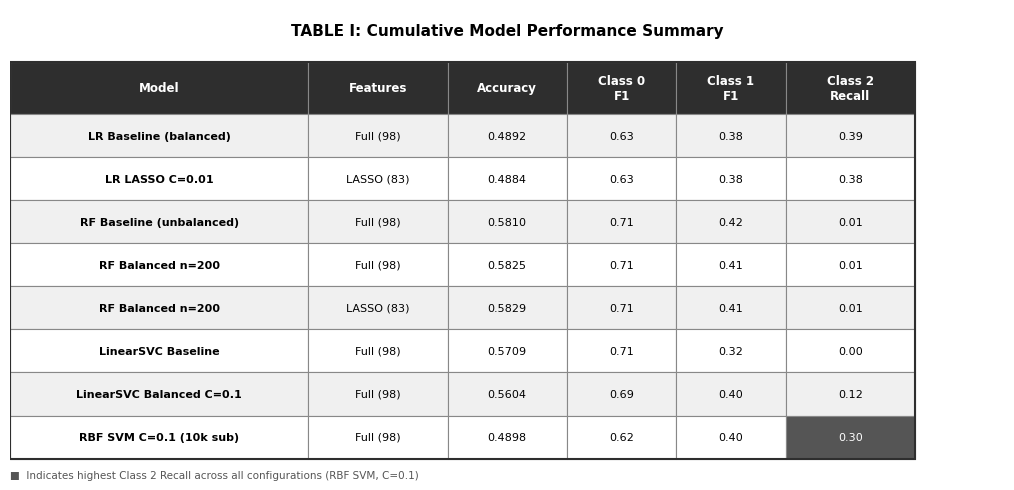

Saved to table_model_comparison.png


In [4]:
fig_width  = 10
row_height = 0.45
header_h   = 0.55
n_rows     = len(rows)
fig_height = header_h + n_rows * row_height + 0.6

fig, ax = plt.subplots(figsize=(fig_width, fig_height))
ax.set_xlim(0, 1)          # coordinate system runs 0 to 1 horizontally
ax.set_ylim(0, fig_height) # coordinate system runs 0 to fig_height vertically
ax.axis('off')             # hid default matplotlib axes and ticks

ax.text(0.5, fig_height - 0.15,
        'TABLE I: Cumulative Model Performance Summary',
        ha='center', va='top', fontsize=11, fontweight='bold')

# I computed column x-start positions from the column widths
x_starts = []
x = 0
for w in col_widths:
    x_starts.append(x)
    x += w

table_top    = fig_height - 0.55
table_bottom = table_top - header_h - n_rows * row_height

# Header row
for j, (label, w, xs) in enumerate(zip(col_labels, col_widths, x_starts)):
    rect = mpatches.FancyBboxPatch(
        (xs, table_top - header_h), w, header_h,
        boxstyle='square,pad=0', linewidth=0.8,
        edgecolor=BORDER, facecolor=HEADER_BG)
    ax.add_patch(rect)
    ax.text(xs + w/2, table_top - header_h/2, label,
            ha='center', va='center',
            fontsize=8.5, fontweight='bold', color=HEADER_FG)

# Data rows
for i, row in enumerate(rows):
    y_top  = table_top - header_h - i * row_height
    bg     = ROW_ALT if i % 2 == 0 else ROW_WHITE
    for j, (cell, w, xs) in enumerate(zip(row, col_widths, x_starts)):
        # I highlighted row 7, col 5: best Class 2 recall (RBF SVM)
        cell_color = HIGHLIGHT if (i == 7 and j == 5) else bg
        text_color = 'white'  if (i == 7 and j == 5) else 'black'
        rect = mpatches.FancyBboxPatch(
            (xs, y_top - row_height), w, row_height,
            boxstyle='square,pad=0', linewidth=0.8,
            edgecolor=BORDER, facecolor=cell_color)
        ax.add_patch(rect)
        ax.text(xs + w/2, y_top - row_height/2, cell,
                ha='center', va='center', fontsize=8, color=text_color,
                fontweight='bold' if j == 0 else 'normal')  # bolded model name column only

# Outer border covering the full table area
total_w = sum(col_widths)
total_h = header_h + n_rows * row_height
outer = mpatches.FancyBboxPatch(
    (0, table_bottom), total_w, total_h,
    boxstyle='square,pad=0', linewidth=1.5,
    edgecolor=HEADER_BG, facecolor='none')  # facecolor='none' draws only the border
ax.add_patch(outer)

# Footnote positioned just below the table
ax.text(0.0, table_bottom - 0.12,
        '\u25a0  Indicates highest Class 2 Recall across all configurations (RBF SVM, C=0.1)',
        ha='left', va='top', fontsize=7.5, color=HIGHLIGHT)

plt.tight_layout(pad=0.2)
plt.savefig('table_model_comparison.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved to table_model_comparison.png')

## 5. Key Takeaways

**Accuracy ceiling:** Overall accuracy stayed between 0.49 and 0.58 across all configurations - three algorithms, two feature sets, multiple hyperparameter sweeps - none broke through this ceiling.

**Class imbalance:** Without class balancing, every model I trained produced zero or near-zero Class 2 recall. With balancing applied, Class 2 recall improved (0.01 in RF → 0.30 in RBF SVM), but always at some cost to overall accuracy.

**Feature selection:** The LASSO feature set (83 features) performed nearly identically to the full set (98 features) across every model I tested, confirming that the 15 dropped features were genuinely uninformative.

**Data structure, not modeling:** The PCA results I produced in `6_PCA_PM.ipynb` showed that the three readmission classes overlapped almost completely in the feature space. The prediction ceiling I observed reflected the limits of what structured discharge data captured - not a failure of any particular algorithm. Patient behavior after discharge, medication adherence, social determinants of health, and access to follow-up care are likely the strongest predictors of readmission but were absent from this dataset. The most important investment going forward would be in the data itself.